Implement Height and Weight using all regression models. Select the Best model and integrate with GUI.

In [174]:
import kagglehub
path = kagglehub.dataset_download("mustafaali96/weight-height")

Using Colab cache for faster access to the 'weight-height' dataset.


In [175]:
import pandas as pd

df = pd.read_csv(path + "/weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [176]:
# Converting units (inches to cm, pound(lb) to kilograms)
df["Height_cm"] = df["Height"] * 2.54
df["Weight_kg"] = df["Weight"] * 0.453592
df.drop(["Height", "Weight"], axis=1, inplace=True)
df.rename(columns={"Height_cm": "Height", "Weight_kg": "Weight"}, inplace=True)
df.head()

,Gender,Height,Weight
0,Male,187.571423,109.720985
1,Male,174.706036,73.622732
2,Male,188.239668,96.497550
3,Male,182.196685,99.809504
4,Male,177.499761,93.598619


In [177]:
corr = df['Height'].corr(df['Weight'])
print(corr)

if corr > 0.5:
    print("Positive correlation")
elif corr < -0.5:
    print("Negative correlation")
else:
    print("No correlation")

0.9247562987409145
Positive correlation


In [178]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(df['Height'], df['Weight'])
print('Pearsons correlation: %.3f' % corr)
print("Pearsons p-value:",p_val)

Pearsons correlation: 0.925
Pearsons p-value: 0.0


In [179]:
df.shape

(10000, 3)

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [181]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,168.573602,73.228054
std,9.772721,14.564131
min,137.828359,29.347460
25%,161.304276,61.605982
50%,168.447898,73.124894
75%,175.702625,84.898599
max,200.656806,122.465167


In [182]:
df.isnull().sum()

,0
Gender,0
Height,0
Weight,0


In [183]:
df.duplicated().sum()

np.int64(0)

In [184]:
# Independent Variable
X = df[['Height']]

# Dependent Variable
y = df['Weight']

print("Independent Variable(X): Height\n", X)
print("\nDependent Variable(y): Weight\n", y)

Independent Variable(X): Height
           Height
0     187.571423
1     174.706036
2     188.239668
3     182.196685
4     177.499761
...          ...
9995  168.078536
9996  170.350573
9997  162.224700
9998  175.346978
9999  157.338385

[10000 rows x 1 columns]

Dependent Variable(y): Weight
 0       109.720985
1        73.622732
2        96.497550
3        99.809504
4        93.598619
           ...    
9995     62.041159
9996     77.504315
9997     58.275377
9998     74.322166
9999     51.550324
Name: Weight, Length: 10000, dtype: float64


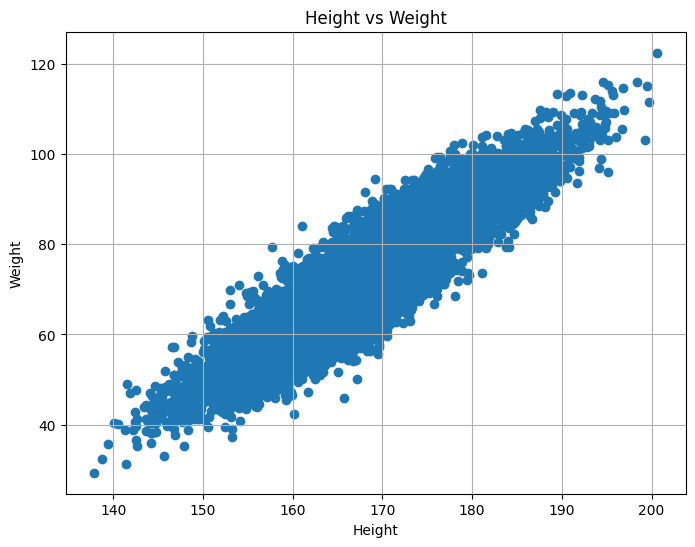

In [185]:
# Scatter Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X, y)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.grid(True)
plt.show()

In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training Data: ",len(X_train))
print("Testing Data: ",len(X_test))

Training Data:  8000
Testing Data:  2000


In [187]:
# Scaling for Ridge & Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [188]:
# Simple Linear Regression
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_y_pred = linear_model.predict(X_test)

print("Linear Regression")
print("Intercept:", linear_model.intercept_)
print("Slope:", linear_model.coef_[0])
print("Regression Equation:")
print("Weight(y) = ",round(linear_model.coef_[0],2),"* Height(x) ",round(linear_model.intercept_,2))

Linear Regression
Intercept: -158.6609571136325
Slope: 1.3754526665301643
Regression Equation:
Weight(y) =  1.38 * Height(x)  -158.66


In [189]:
# Ridge Regression
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_y_pred = ridge_model.predict(X_test_scaled) # scaled data

print("Ridge Regression")
print("Alpha:", ridge_model.alpha)
print("Intercept:", round(ridge_model.intercept_,2))
print("Slope:", round(ridge_model.coef_[0],2))

Ridge Regression
Alpha: 1.0
Intercept: 73.18
Slope: 13.43


In [190]:
# Lasso Regression
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)
lasso_y_pred = lasso_model.predict(X_test_scaled) # scaled data

print("Lasso Regression")
print("Alpha:", lasso_model.alpha)
print("Intercept:", round(lasso_model.intercept_,2))
print("Slope:", round(lasso_model.coef_[0],2))

Lasso Regression
Alpha: 1.0
Intercept: 73.18
Slope: 12.43


In [191]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=4,random_state=42)
dt_model.fit(X_train, y_train)
dt_y_pred = dt_model.predict(X_test)

print("Decision Tree")
print("Maximun Depth:",dt_model.max_depth)
print("Number of Nodes:",dt_model.tree_.node_count)

Decision Tree
Maximun Depth: 4
Number of Nodes: 31


In [192]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth = 4)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

print("Random Forest")
print("Number of Trees:",rf_model.n_estimators)
print("Maximum Depth:",rf_model.max_depth)
print("Number of Nodes:",rf_model.n_estimators * rf_model.max_depth)

Random Forest
Number of Trees: 100
Maximum Depth: 4
Number of Nodes: 400


In [193]:
# Compare all models
predition = {
    "Linear Regression": linear_y_pred,
    "Ridge Regression": ridge_y_pred,
    "Lasso Regression": lasso_y_pred,
    "Decision Tree": dt_y_pred,
    "Random Forest": rf_y_pred
}

In [194]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
results = []

for model_name,y_pred in predition.items():
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([model_name, mse, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=['Model', 'MSE', 'MAE', 'RMSE', 'R2'])

In [195]:
print("MODEL PERFORMANCE COMAPRISON")
print("=" * 70)
print(results_df.round(4).to_string(index=False))

MODEL PERFORMANCE COMAPRISON
            Model     MSE    MAE   RMSE     R2
Linear Regression 30.6568 4.3962 5.5369 0.8577
 Ridge Regression 30.7183 4.4002 5.5424 0.8574
 Lasso Regression 32.0406 4.5377 5.6604 0.8513
    Decision Tree 31.6795 4.4993 5.6285 0.8530
    Random Forest 30.6606 4.4015 5.5372 0.8577


In [196]:
comparison = pd.DataFrame({
    'Height': X_test['Height'].values,
    'Actual Weight': y_test,
    'Linear Regression': linear_y_pred,
    'Ridge Regression': ridge_y_pred,
    'Lasso Regression': lasso_y_pred,
    'Decision Tree': dt_y_pred,
    'Random Forest': rf_y_pred
})

comparison = comparison.sort_values(by = 'Height')

In [197]:
print("ACTUAL VS PREDICTED WEIGHT")
print(comparison.round(2).to_string(index=False))

ACTUAL VS PREDICTED WEIGHT
 Height  Actual Weight  Linear Regression  Ridge Regression  Lasso Regression  Decision Tree  Random Forest
 141.58          49.04              36.07             36.03             38.79          45.90          45.32
 141.86          47.07              36.46             36.41             39.15          45.90          45.32
 142.41          40.63              37.22             37.17             39.84          45.90          45.32
 142.66          35.33              37.57             37.52             40.17          45.90          45.32
 143.37          43.84              38.54             38.49             41.06          45.90          45.32
 143.63          38.50              38.90             38.84             41.39          45.90          45.32
 143.96          44.12              39.35             39.30             41.81          45.90          45.32
 144.24          38.10              39.73             39.67             42.16          45.90          45.32
 

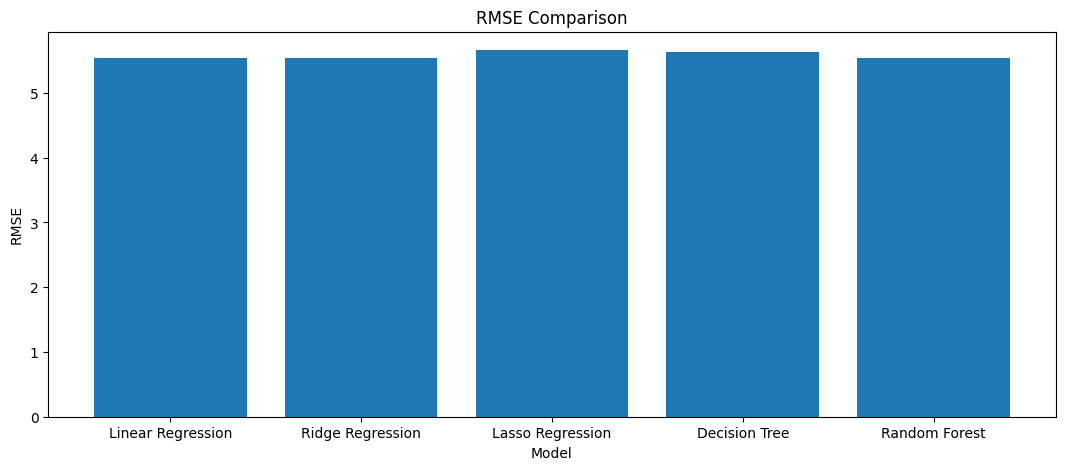

In [198]:
# Bar Plot for RMSE
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 5))
plt.bar(results_df['Model'], results_df['RMSE'])
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.show()

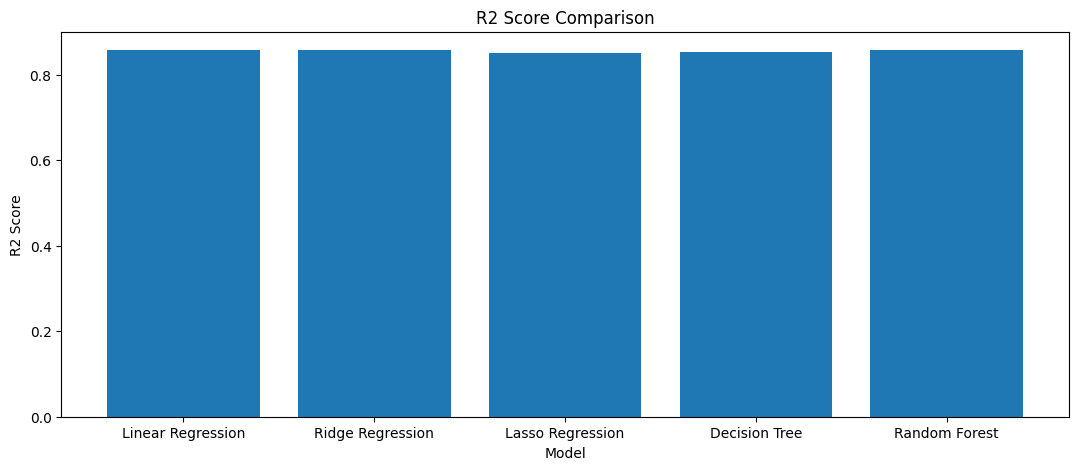

In [199]:
# Bar Plot for R2 Score
plt.figure(figsize=(13, 5))
plt.bar(results_df['Model'], results_df['R2'])
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('R2 Score Comparison')
plt.show()

In [200]:
models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Decision Tree Regression': dt_model,
    'Random Forest Regression': rf_model
}

In [201]:
best_model_name = results_df.loc[results_df["R2"].idxmax(),"Model"]
best_model1 = models[best_model_name]
best_model1

LinearRegression()

In [202]:
# distribute x values
X_range = np.linspace(X['Height'].min(),X['Height'].max(),200).reshape(-1,1)

In [203]:
# PREDICTIONS FOR SMOOTH CURVES
linear_curve = linear_model.predict(X_range)
ridge_curve = ridge_model.predict((scaler.transform(X_range)))
lasso_curve = lasso_model.predict((scaler.transform(X_range)))
dt_curve = dt_model.predict(X_range)
rf_curve = rf_model.predict(X_range)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


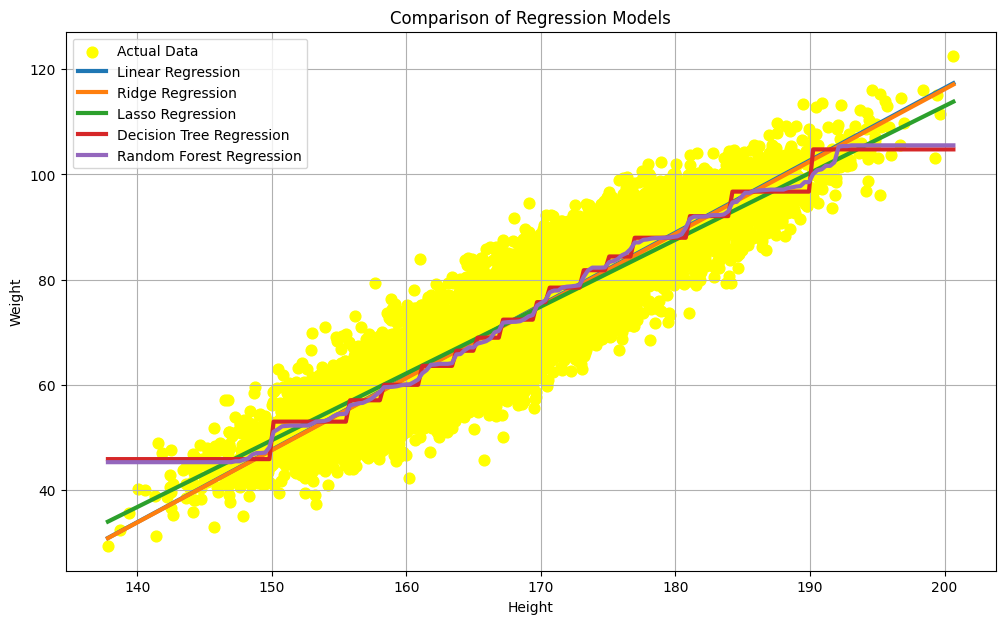

In [204]:
# PLOT ALL REGRESSION MODELS
plt.figure(figsize=(12,7))
# Actual Data
plt.scatter(X, y, s = 60, label='Actual Data',color='yellow')
# Linear Regression
plt.plot(X_range,linear_curve,linewidth=3, label='Linear Regression')
# Ridge Regression
plt.plot(X_range,ridge_curve,linewidth=3, label='Ridge Regression')
# Lasso Regression
plt.plot(X_range,lasso_curve,linewidth=3, label='Lasso Regression')
# Decision Tree Regression
plt.plot(X_range,dt_curve,linewidth=3, label='Decision Tree Regression')
# Random Forest Regression
plt.plot(X_range,rf_curve,linewidth=3, label='Random Forest Regression')

plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Comparison of Regression Models')
plt.legend()
plt.grid(True)
plt.show()

In [209]:
new_height = [[171]]
new_linear = linear_model.predict(new_height)[0]
new_ridge = ridge_model.predict(scaler.transform(new_height))[0]
new_lasso = lasso_model.predict(scaler.transform(new_height))[0]
new_tree = dt_model.predict(new_height)[0]
new_forest = rf_model.predict(new_height)[0]

prediction_result = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Decision Tree Regression', 'Random Forest Regression'],
    'Predicted Weight': [new_linear, new_ridge, new_lasso, new_tree, new_forest]
})
print("PREDICTION FOR NEW HEIGHT")
print("Height:", new_height[0][0])
print(prediction_result.round(2).to_string(index=False))

PREDICTION FOR NEW HEIGHT
Height: 171
                   Model  Predicted Weight
       Linear Regression             76.54
        Ridge Regression             76.40
        Lasso Regression             76.16
Decision Tree Regression             78.49
Random Forest Regression             77.93


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [207]:
print("Minimum Height:", df["Height"].min())
print("Maximum Height:", df["Height"].max())

print("Correlation:",
      df["Height"].corr(df["Weight"]))

Minimum Height: 137.82835864574665
Maximum Height: 200.6568055598296
Correlation: 0.9247562987409145


In [210]:
# Pickle File: stores the entire trained model(code)
import joblib

joblib.dump(best_model1,'best_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [211]:
model = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')